# LoanTap — Personal Loan Underwriting (Logistic Regression)

**Business Case Study | EDA, Feature Engineering, Logistic Regression, Precision-Recall Tradeoff**

## 1. Problem Statement

LoanTap offers instant, flexible credit products to salaried millennials. This notebook focuses
on the **Personal Loan** underwriting process: given an applicant's financial and credit-profile
attributes, **should LoanTap extend a credit line, and on what terms?**

Concretely, we build a model to predict whether a loan will be **Charged Off (defaulted)** vs
**Fully Paid**, so that this probability can drive the underwriting decision. Getting this right
matters on both sides: approving too many risky applicants raises **NPAs (non-performing
assets)**, while rejecting too many good applicants means **lost interest income and business
growth**. This notebook builds that model, rigorously evaluates it, and translates the results
into a concrete underwriting recommendation for LoanTap.


In [1]:
from IPython.display import display, HTML
display(HTML("<style>pre { white-space: pre-wrap !important; }</style>"))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              precision_recall_curve, confusion_matrix, f1_score,
                              precision_score, recall_score, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
np.random.seed(42)

df = pd.read_csv("logistic_regression.csv")
print(df.head())


   loan_amnt        term  int_rate  installment grade sub_grade  \
0    10000.0   36 months     11.44       329.48     B        B4   
1     8000.0   36 months     11.99       265.68     B        B5   
2    15600.0   36 months     10.49       506.97     B        B3   
3     7200.0   36 months      6.49       220.65     A        A2   
4    24375.0   60 months     17.27       609.33     C        C5   

                 emp_title emp_length home_ownership  annual_inc  \
0                Marketing  10+ years           RENT    117000.0   
1          Credit analyst     4 years       MORTGAGE     65000.0   
2             Statistician   < 1 year           RENT     43057.0   
3          Client Advocate    6 years           RENT     54000.0   
4  Destiny Management Inc.    9 years       MORTGAGE     55000.0   

  verification_status   issue_d  loan_status             purpose  \
0        Not Verified  Jan-2015   Fully Paid            vacation   
1        Not Verified  Jan-2015   Fully Paid  debt_c

## 2. Basic Data Checks

In [2]:
print("Shape of dataset:", df.shape)
print()
df.info()


Shape of dataset: (396030, 27)

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 no

In [3]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
emp_title               22927
emp_length              18301
title                    1756
revol_util                276
mort_acc                37795
pub_rec_bankruptcies      535
dtype: int64

Duplicate rows: 0


In [4]:
print("Statistical summary (numeric columns):")
print(df.describe().T)


Statistical summary (numeric columns):
                         count          mean           std     min       25%  \
loan_amnt             396030.0  14113.888089   8357.441341  500.00   8000.00   
int_rate              396030.0     13.639400      4.472157    5.32     10.49   
installment           396030.0    431.849698    250.727790   16.08    250.33   
annual_inc            396030.0  74203.175798  61637.621158    0.00  45000.00   
dti                   396030.0     17.379514     18.019092    0.00     11.28   
open_acc              396030.0     11.311153      5.137649    0.00      8.00   
pub_rec               396030.0      0.178191      0.530671    0.00      0.00   
revol_bal             396030.0  15844.539853  20591.836109    0.00   6025.00   
revol_util            395754.0     53.791749     24.452193    0.00     35.80   
total_acc             396030.0     25.414744     11.886991    2.00     17.00   
mort_acc              358235.0      1.813991      2.147930    0.00      0.00   
p

In [5]:
print("Target variable distribution:")
print(df["loan_status"].value_counts())
print(df["loan_status"].value_counts(normalize=True).round(4) * 100)


Target variable distribution:
loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64
loan_status
Fully Paid     80.39
Charged Off    19.61
Name: proportion, dtype: float64


**Observations**
- **396,030 loan applications, 27 columns**, no duplicate rows.
- Missing values exist in `emp_title` (~5.8%), `emp_length` (~4.6%), `title` (~0.4%), `revol_util` (~0.07%), `mort_acc` (~9.5%), and `pub_rec_bankruptcies` (~0.1%) — handled in Section 5.
- The **target variable `loan_status`** has only two relevant outcomes here — **Fully Paid (80.4%)** and **Charged Off (19.6%)** — a real but moderate class imbalance (roughly 4:1), which we address during modeling (Section 8).
- `loan_amnt`, `int_rate`, `installment`, `annual_inc`, `dti`, `revol_bal` are continuous; `grade`/`sub_grade`/`emp_length`/`term` are ordinal-like categoricals; `home_ownership`, `verification_status`, `purpose`, `initial_list_status`, `application_type` are nominal categoricals.

## 3. Univariate Analysis

### 3.1 Continuous variables — distributions

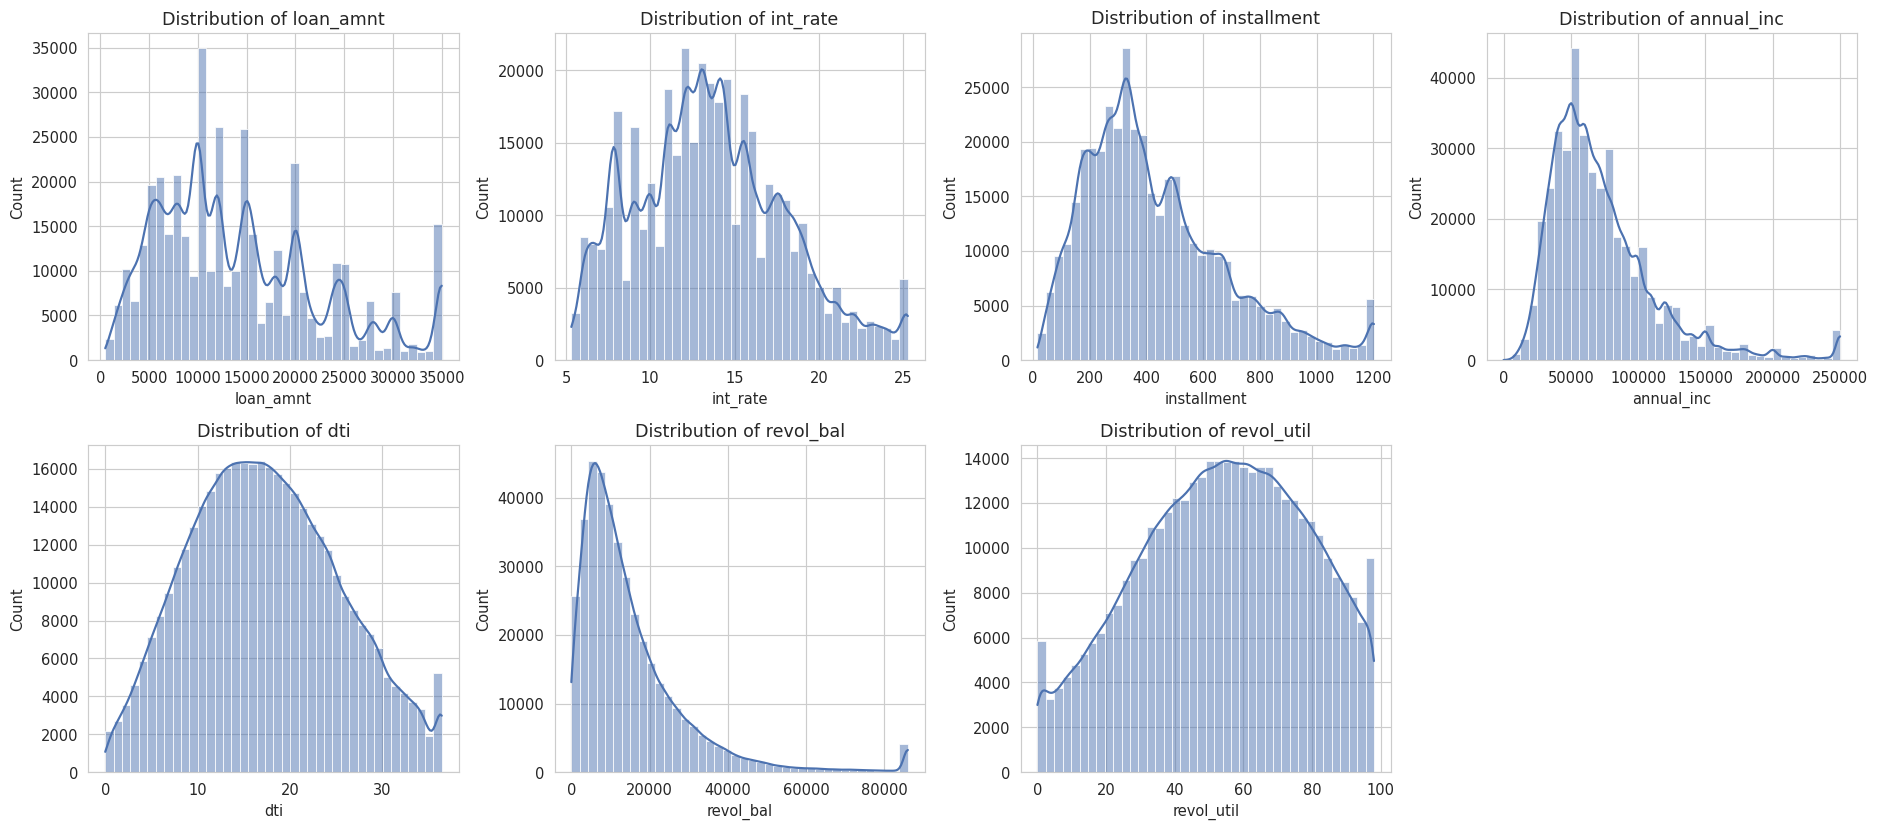

In [6]:
cont_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "revol_bal", "revol_util"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cont_cols):
    sns.histplot(df[col].clip(upper=df[col].quantile(0.99)), kde=True, ax=ax, bins=40, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()


### 3.2 Categorical variables — count plots

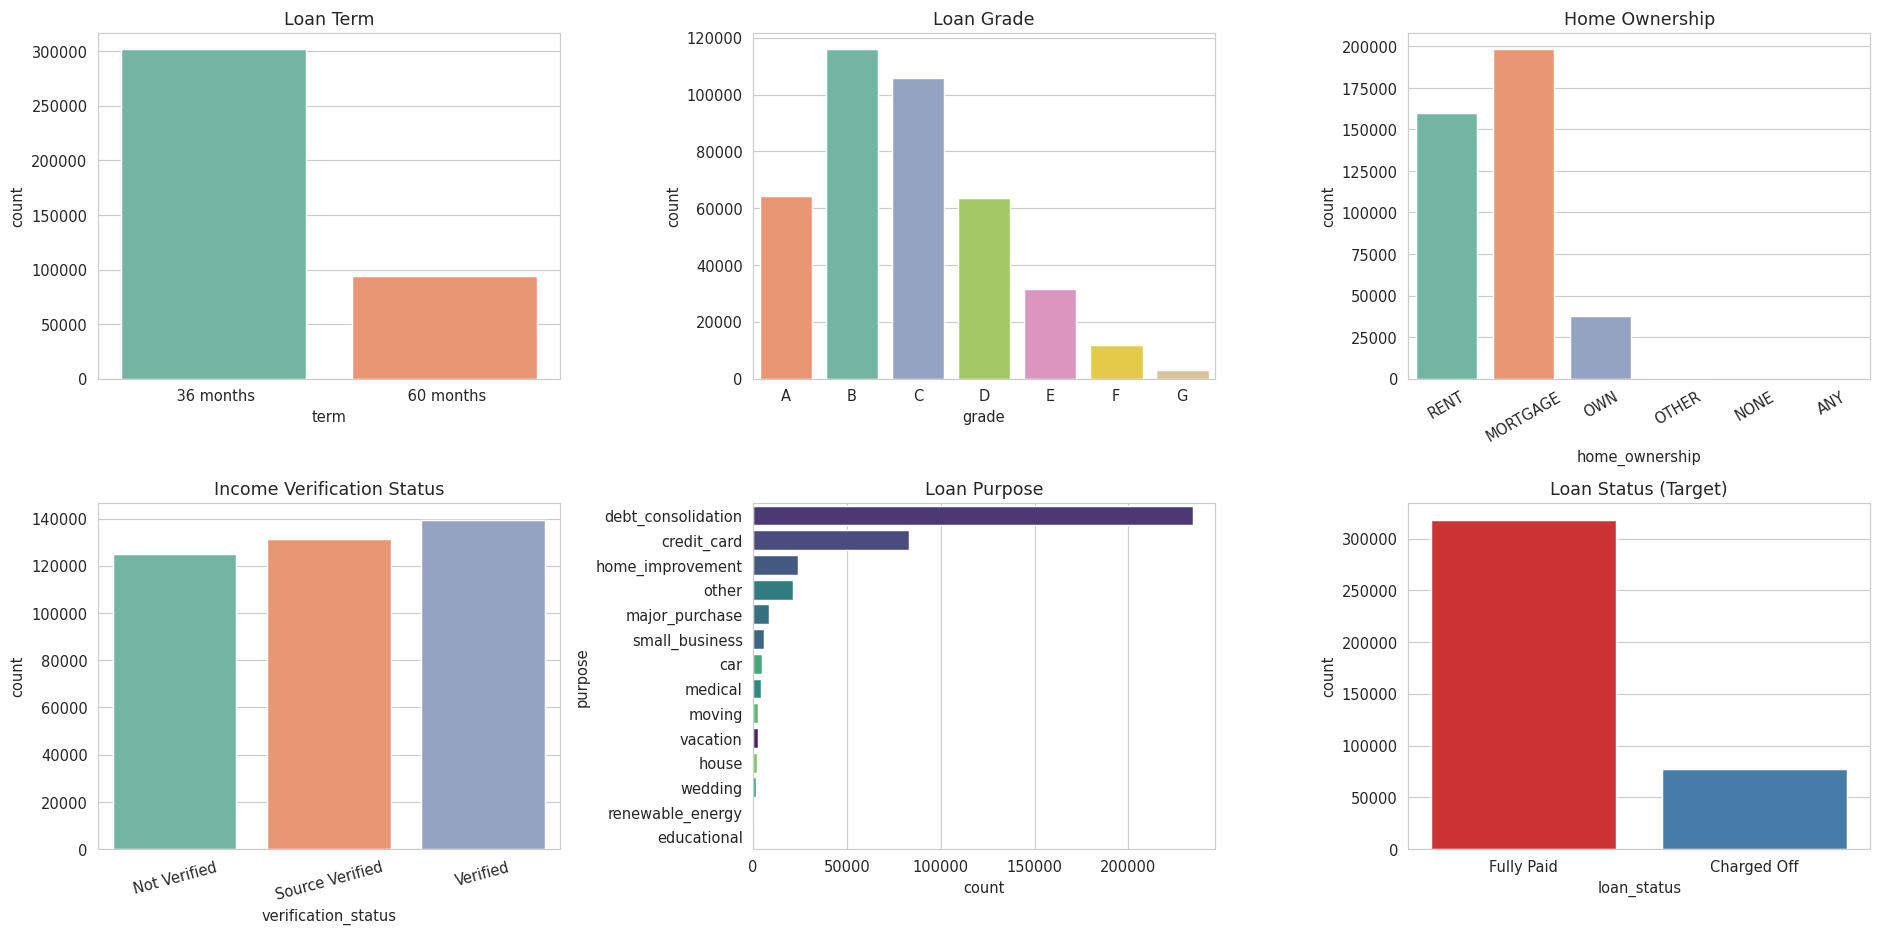

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
sns.countplot(x="term", data=df, ax=axes[0,0], hue="term", palette="Set2", legend=False)
axes[0,0].set_title("Loan Term")
sns.countplot(x="grade", data=df, order=sorted(df["grade"].unique()), ax=axes[0,1], hue="grade", palette="Set2", legend=False)
axes[0,1].set_title("Loan Grade")
sns.countplot(x="home_ownership", data=df, ax=axes[0,2], hue="home_ownership", palette="Set2", legend=False)
axes[0,2].set_title("Home Ownership")
axes[0,2].tick_params(axis="x", rotation=30)
sns.countplot(x="verification_status", data=df, ax=axes[1,0], hue="verification_status", palette="Set2", legend=False)
axes[1,0].set_title("Income Verification Status")
axes[1,0].tick_params(axis="x", rotation=15)
sns.countplot(y="purpose", data=df, order=df["purpose"].value_counts().index, ax=axes[1,1], hue="purpose", palette="viridis", legend=False)
axes[1,1].set_title("Loan Purpose")
sns.countplot(x="loan_status", data=df, ax=axes[1,2], hue="loan_status", palette="Set1", legend=False)
axes[1,2].set_title("Loan Status (Target)")
plt.tight_layout()
plt.show()


**Observations**
- `loan_amnt`, `installment`, `annual_inc`, `revol_bal` are all **right-skewed** — most loans/incomes are modest, with a long tail of large loans and high earners.
- `int_rate` and `dti` are close to symmetric/mildly right-skewed; `revol_util` (percent of revolving credit used) is fairly uniform across 0-100%.
- **36-month loans dominate** (76%) over 60-month loans; **Grade B and C loans are the most common** (together ~56% of all loans), with very few G-grade (highest risk) loans.
- **MORTGAGE is the most common home-ownership status** (50%), followed by RENT (40%) and OWN (9.5%).
- **`debt_consolidation` is by far the most common loan purpose** (59%), followed by `credit_card` (21%) — LoanTap's personal loans are overwhelmingly used to restructure existing debt, not for new discretionary spending.
- The target confirms the **80/20 class imbalance** noted above.

## 4. Bivariate Analysis — Relationship with Loan Status

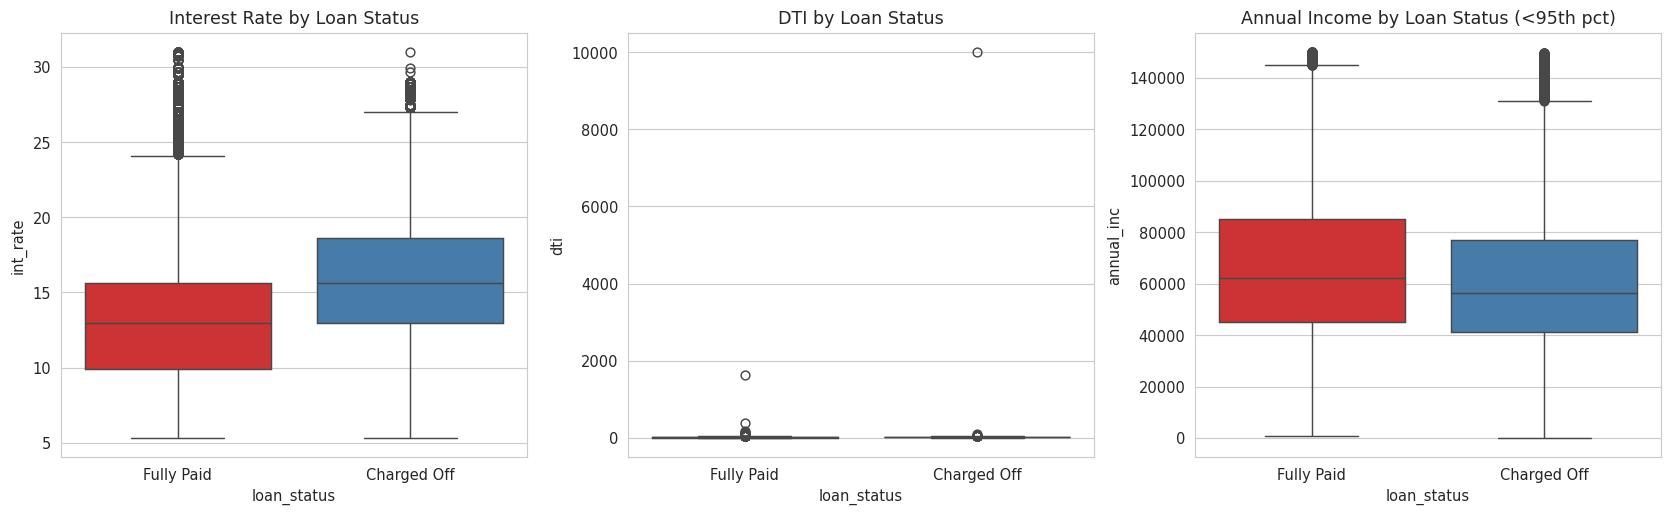

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.boxplot(x="loan_status", y="int_rate", data=df, ax=axes[0], hue="loan_status", palette="Set1", legend=False)
axes[0].set_title("Interest Rate by Loan Status")
sns.boxplot(x="loan_status", y="dti", data=df, ax=axes[1], hue="loan_status", palette="Set1", legend=False)
axes[1].set_title("DTI by Loan Status")
sns.boxplot(x="loan_status", y="annual_inc", data=df[df["annual_inc"] < df["annual_inc"].quantile(0.95)],
            ax=axes[2], hue="loan_status", palette="Set1", legend=False)
axes[2].set_title("Annual Income by Loan Status (<95th pct)")
plt.tight_layout()
plt.show()


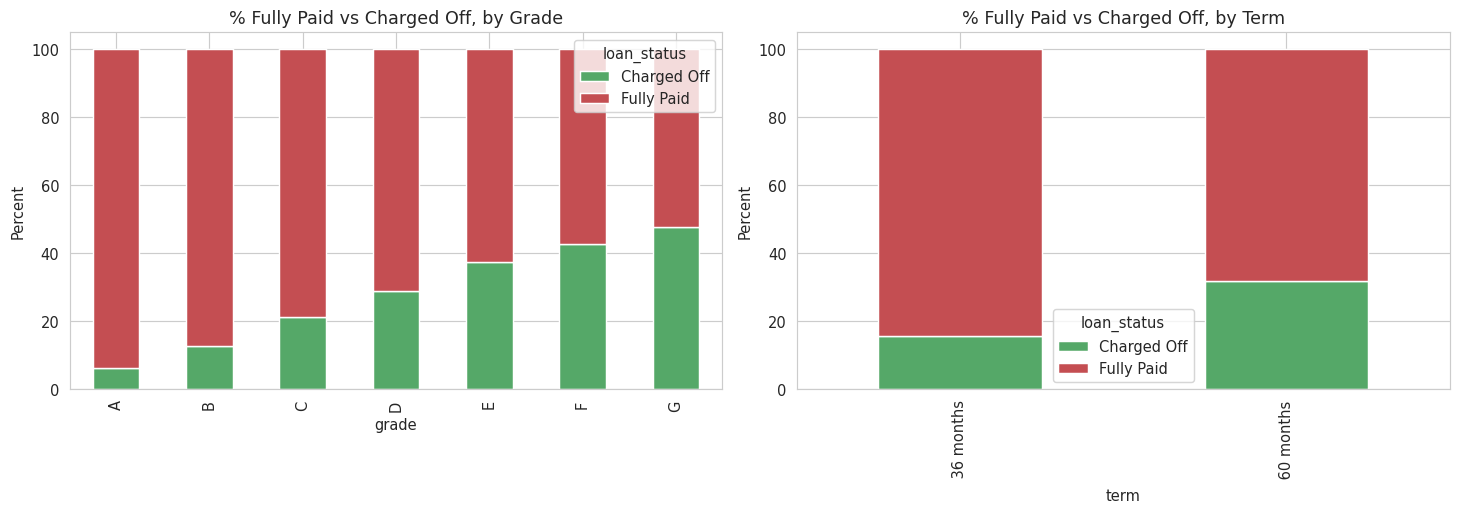

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
grade_status = pd.crosstab(df["grade"], df["loan_status"], normalize="index").sort_index() * 100
grade_status.plot(kind="bar", stacked=True, ax=axes[0], color=["#55A868","#C44E52"])
axes[0].set_title("% Fully Paid vs Charged Off, by Grade")
axes[0].set_ylabel("Percent")

term_status = pd.crosstab(df["term"], df["loan_status"], normalize="index") * 100
term_status.plot(kind="bar", stacked=True, ax=axes[1], color=["#55A868","#C44E52"])
axes[1].set_title("% Fully Paid vs Charged Off, by Term")
axes[1].set_ylabel("Percent")
plt.tight_layout()
plt.show()


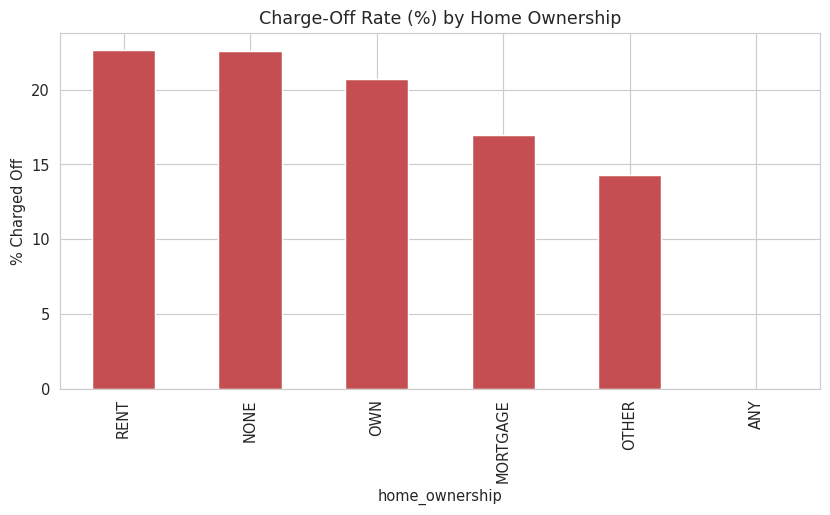

In [10]:
plt.figure(figsize=(8,5))
home_status = pd.crosstab(df["home_ownership"], df["loan_status"], normalize="index") * 100
home_status["Charged Off"].sort_values(ascending=False).plot(kind="bar", color="#C44E52")
plt.title("Charge-Off Rate (%) by Home Ownership")
plt.ylabel("% Charged Off")
plt.tight_layout()
plt.show()


**Observations**
- **Charged-off loans have a visibly higher median interest rate** than fully-paid loans — makes sense, since LoanTap's own risk-based pricing already charges riskier borrowers more.
- **Charged-off loans have a higher median DTI** (debt-to-income) — borrowers already carrying more debt relative to income are more likely to default, as expected.
- Annual income shows the opposite pattern only mildly — charged-off borrowers skew slightly lower income, but with heavy overlap; income alone is a weak signal.
- **Charge-off rate rises steadily and almost monotonically from Grade A (6.3%) to Grade G (47.8%)** — nearly 8x higher for the riskiest grade — confirming LoanTap's own risk-grading system is already strongly predictive of actual default.
- **60-month loans charge off twice as often as 36-month loans** (31.9% vs 15.8%) — longer-term loans are meaningfully riskier, consistent with more time for a borrower's situation to change.
- **Home-ownership status shows a real gap**: RENT and NONE borrowers charge off at ~22-23%, vs. MORTGAGE at ~17% — owning property (even with a mortgage) is a marker of financial stability.

## 5. Correlation Among Independent Variables

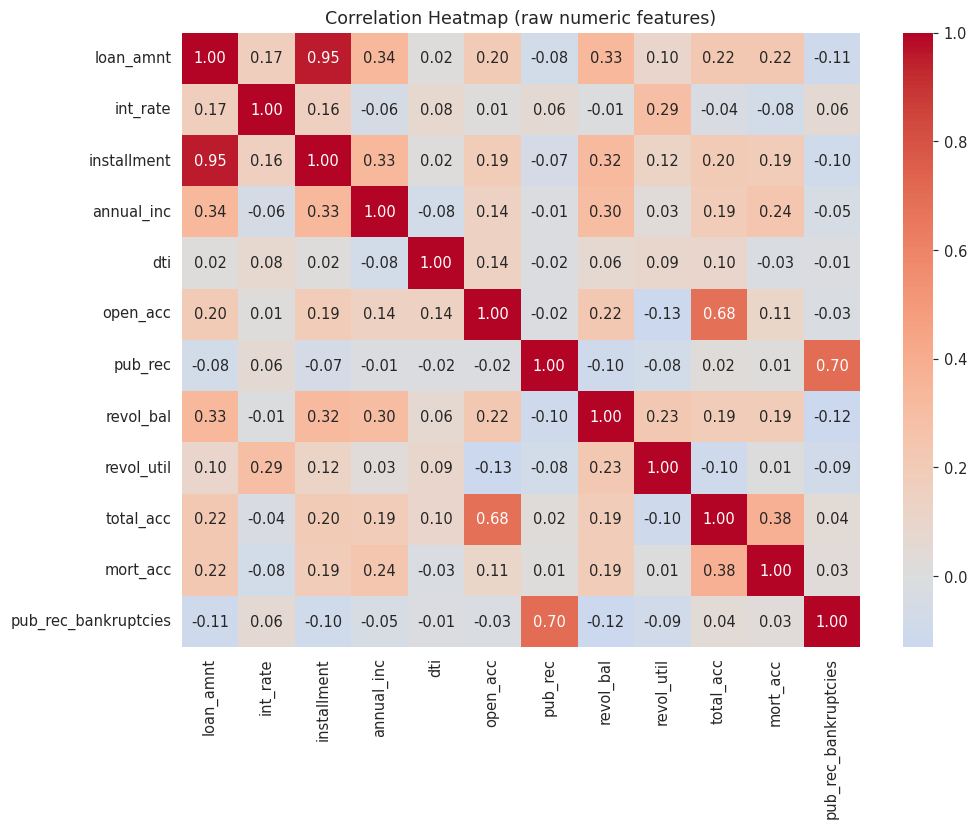

In [11]:
num_cols_corr = ["loan_amnt","int_rate","installment","annual_inc","dti","open_acc",
                  "pub_rec","revol_bal","revol_util","total_acc","mort_acc","pub_rec_bankruptcies"]
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (raw numeric features)")
plt.tight_layout()
plt.show()


**Observations**
- **`loan_amnt` and `installment` are very strongly correlated (0.95)** — expected, since installment is mathematically derived from loan amount, interest rate, and term. This is a strong multicollinearity signal we formally address via VIF after feature engineering (Section 9).
- **`pub_rec` and `pub_rec_bankruptcies` are moderately-to-strongly correlated (~0.70)** — bankruptcies are a subset of derogatory public records, so some overlap is expected.
- Most other predictor pairs show weak-to-moderate correlation (<0.4) — limited redundancy elsewhere.

## 6. Data Preprocessing

### 6.1 Duplicate check (repeated for completeness)

In [12]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


### 6.2 Missing value treatment

We treat each column based on *why* it's missing and how useful it is:
- **`emp_title`** (5.8% missing, thousands of free-text job titles): too high-cardinality and noisy to encode usefully -> **drop the column**.
- **`title`** (0.4% missing): a free-text restatement of `purpose` (already a clean category) -> **drop the column**.
- **`emp_length`** (4.6% missing): convert to a numeric scale (0-10) first, then impute missing with the **median**.
- **`revol_util`** (0.07% missing) and **`pub_rec_bankruptcies`** (0.1% missing): impute with **median** / **0** respectively — negligible missingness, simple imputation is safe.
- **`mort_acc`** (9.5% missing, the largest gap): rather than a blind median fill, we impute using the **mean `mort_acc` for other borrowers with the same `total_acc`** (their strongest correlate, r≈0.38) — a smarter, relationship-aware imputation.

In [13]:
emp_map = {"< 1 year":0, "1 year":1, "2 years":2, "3 years":3, "4 years":4, "5 years":5,
           "6 years":6, "7 years":7, "8 years":8, "9 years":9, "10+ years":10}
df["emp_length_num"] = df["emp_length"].map(emp_map)
df["emp_length_num"] = df["emp_length_num"].fillna(df["emp_length_num"].median())

df["revol_util"] = df["revol_util"].fillna(df["revol_util"].median())
df["pub_rec_bankruptcies"] = df["pub_rec_bankruptcies"].fillna(0)

mort_by_total_acc = df.groupby("total_acc")["mort_acc"].transform("mean")
df["mort_acc"] = df["mort_acc"].fillna(mort_by_total_acc)
df["mort_acc"] = df["mort_acc"].fillna(df["mort_acc"].median())   # catches any leftover edge cases

df = df.drop(columns=["emp_title", "title"])

print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Remaining missing values:
emp_length    18301
dtype: int64


### 6.3 Outlier detection & treatment

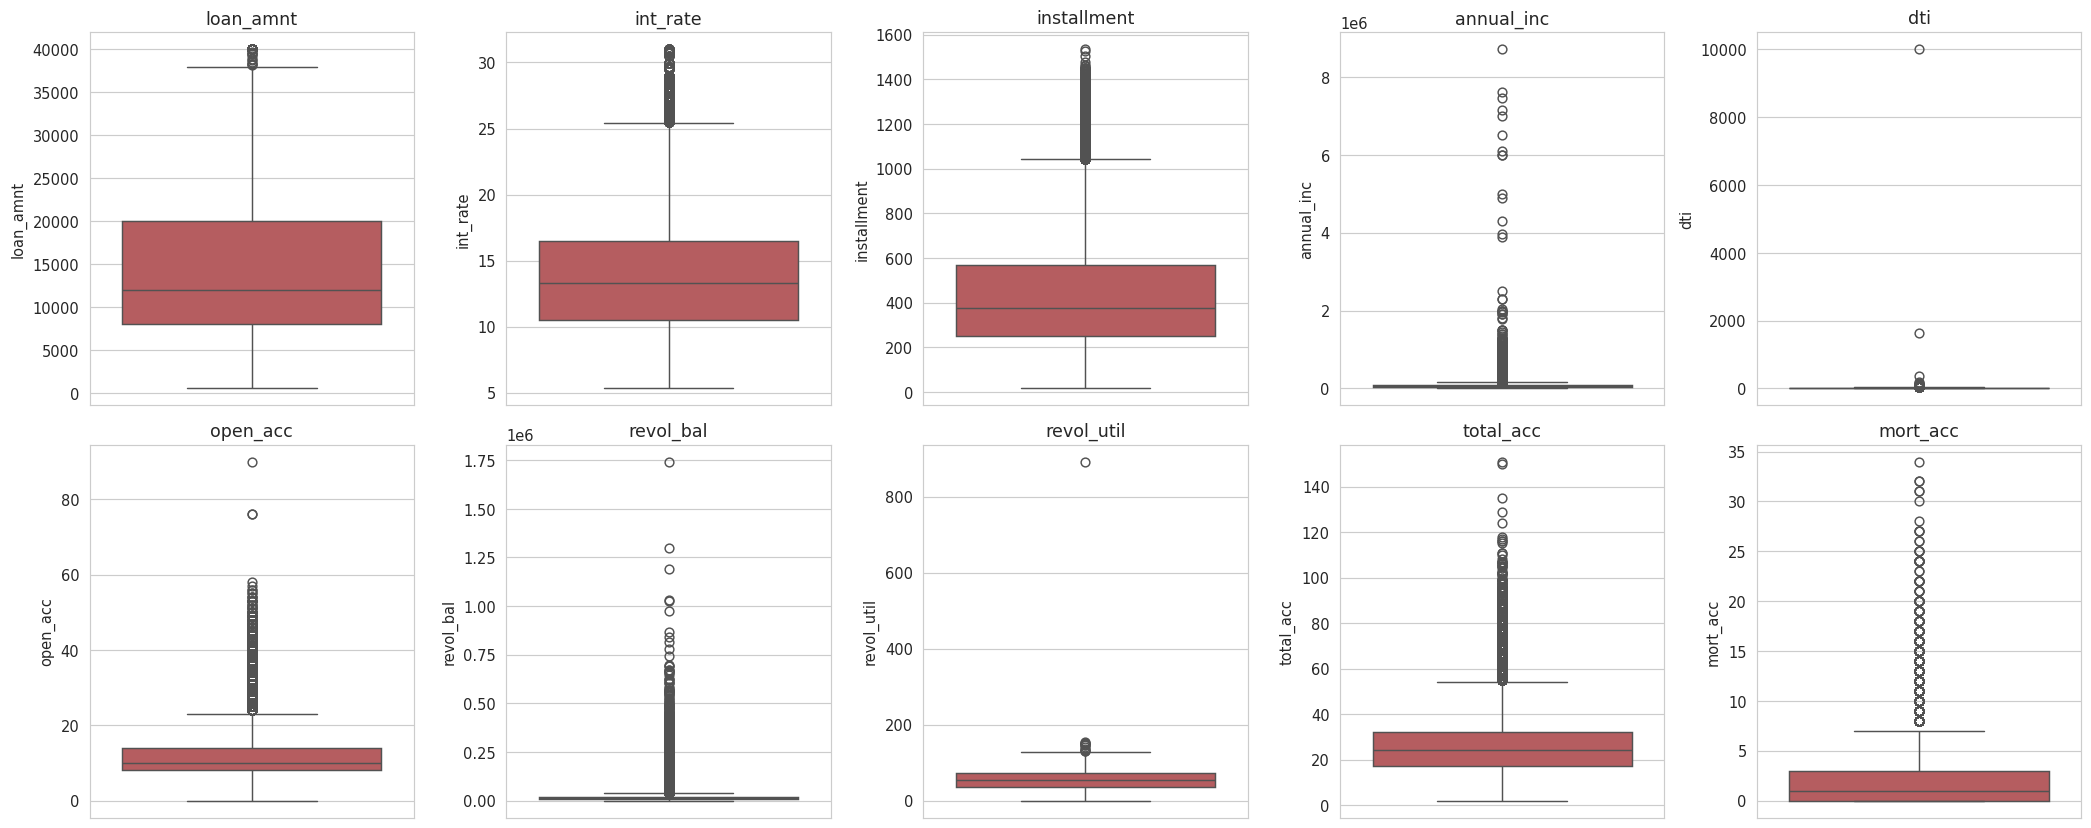

In [14]:
outlier_check_cols = ["loan_amnt","int_rate","installment","annual_inc","dti","open_acc",
                       "revol_bal","revol_util","total_acc","mort_acc"]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flatten(), outlier_check_cols):
    sns.boxplot(y=df[col], ax=ax, color="#C44E52")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [15]:
def outlier_pct(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < lo) | (s > hi)).mean() * 100

for c in outlier_check_cols:
    print(f"{c}: {outlier_pct(df[c]):.2f}% outliers")


loan_amnt: 0.05% outliers
int_rate: 0.95% outliers
installment: 2.84% outliers
annual_inc: 4.22% outliers
dti: 0.07% outliers
open_acc: 2.60% outliers
revol_bal: 5.37% outliers
revol_util: 0.00% outliers
total_acc: 2.15% outliers
mort_acc: 1.73% outliers


**Treatment:** Every column shows some IQR-flagged "outliers," but they're mostly **genuine high-end values** (high earners, large revolving balances, long-established borrowers), not data errors — `annual_inc` (4.2%) and `revol_bal` (5.4%) have the most. Rather than deleting these rows (which would bias the model against exactly the high-value, high-balance applicants a lender most needs to underwrite correctly), we **cap (winsorize) the continuous features at their IQR fences** during feature preparation (Section 7.3) — this limits the influence of extreme values on the model without discarding any applicant.

## 7. Feature Engineering

### 7.1 Binary flags for rare derogatory events

`pub_rec`, `mort_acc`, and `pub_rec_bankruptcies` are heavily zero-inflated (most borrowers have
0). We add binary "has any" flags alongside the raw counts, since *whether* a borrower has ever
had one of these events may matter more than the exact count.

In [16]:
for c in ["pub_rec", "mort_acc", "pub_rec_bankruptcies"]:
    df[c + "_flag"] = (df[c].fillna(0) > 0).astype(int)
    print(f"{c}_flag distribution:")
    print(df[c + "_flag"].value_counts(normalize=True).round(3))
    print()


pub_rec_flag distribution:
pub_rec_flag
0    0.854
1    0.146
Name: proportion, dtype: float64

mort_acc_flag distribution:
mort_acc_flag
1    0.647
0    0.353
Name: proportion, dtype: float64

pub_rec_bankruptcies_flag distribution:
pub_rec_bankruptcies_flag
0    0.886
1    0.114
Name: proportion, dtype: float64



### 7.2 Date-based features

- `earliest_cr_line` and `issue_d` let us compute **`credit_hist_years`** — how many years of credit history the borrower had *at the time the loan was issued*. Longer credit history generally signals a more established, lower-risk borrower.
- `issue_d` itself (the exact funding month) isn't something LoanTap knows *before* a decision, and mixes in macroeconomic timing effects rather than borrower risk -- we compute it only as an intermediate step for `credit_hist_years` and then drop it, so it doesn't leak into the model.

In [17]:
df["issue_year"] = pd.to_datetime(df["issue_d"], format="%b-%Y").dt.year
df["earliest_cr_year"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y").dt.year
df["credit_hist_years"] = df["issue_year"] - df["earliest_cr_year"]

print(df["credit_hist_years"].describe())


count    396030.000000
mean         15.771406
std           7.204763
min           3.000000
25%          11.000000
50%          14.000000
75%          19.000000
max          70.000000
Name: credit_hist_years, dtype: float64


### 7.3 Geographic feature from Address

We extract the **state** abbreviation from the free-text `address` field (the zip code itself is too granular/noisy to use directly, but the state is a clean, low-cardinality category).

In [18]:
df["state"] = df["address"].str.extract(r"([A-Z]{2})\s*\d{5}\s*$")
print(df["state"].value_counts().head(10))
print("Missing states:", df["state"].isnull().sum())


state
AP    14308
AE    14157
AA    13919
NJ     7091
WI     7081
LA     7068
NV     7038
AK     7034
MA     7022
VA     7022
Name: count, dtype: int64
Missing states: 0


### 7.4 Mapping ordinal categories to numbers

`grade` (A-G) and `term` (36/60 months) both have a natural order, so we map them to numbers
directly rather than one-hot encoding (which would throw away the ordering information).

In [19]:
grade_map = {"A":1, "B":2, "C":3, "D":4, "E":5, "F":6, "G":7}
df["grade_num"] = df["grade"].map(grade_map)
df["term_num"] = df["term"].str.extract(r"(\d+)").astype(int)

print(df[["grade","grade_num","term","term_num"]].drop_duplicates().sort_values("grade_num"))


     grade  grade_num        term  term_num
3        A          1   36 months        36
180      A          1   60 months        60
8        B          2   60 months        60
0        B          2   36 months        36
5        C          3   36 months        36
4        C          3   60 months        60
40       D          4   60 months        60
24       D          4   36 months        36
16       E          5   60 months        60
72       E          5   36 months        36
125      F          6   36 months        36
66       F          6   60 months        60
87       G          7   60 months        60
1048     G          7   36 months        36


### 7.5 Outlier capping (IQR winsorization)

In [20]:
cap_cols = ["annual_inc", "revol_bal", "total_acc", "open_acc", "mort_acc", "installment",
            "int_rate", "credit_hist_years"]
for c in cap_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    df[c] = df[c].clip(lower=max(lo, 0), upper=hi)

print("Capping complete. New ranges:")
print(df[cap_cols].describe().loc[["min","max"]])


Capping complete. New ranges:
     annual_inc  revol_bal  total_acc  open_acc  mort_acc  installment  \
min         0.0        0.0        2.0       0.0       0.0       16.080   
max    157500.0    40012.5       54.5      23.0       7.5     1042.755   

     int_rate  credit_hist_years  
min      5.32                3.0  
max     25.49               31.0  


## 8. Data Preparation for Modeling

- **Target:** `default` = 1 if `loan_status` is "Charged Off", 0 if "Fully Paid".
- **Encoding strategy:**
  - `grade` and `term` -> already label/ordinal-encoded above (`grade_num`, `term_num`), since they have a natural order.
  - `home_ownership`, `verification_status`, `purpose`, `initial_list_status`, `application_type` -> **one-hot encoded** (nominal, no inherent order).
  - `state` -> one-hot encoded, but first bucketed to the **top 10 most frequent states + "OTHER"**, to avoid an explosion of 50+ sparse columns.
- **Drop:** `sub_grade` (redundant with `grade`/`int_rate`), `issue_d`/`earliest_cr_line`/`issue_year`/`earliest_cr_year` (already captured in `credit_hist_years`), `address`/`state` raw text (replaced by `state_grp` dummies), `loan_status` (replaced by numeric `default`).
- **Train-test split:** 80/20, stratified on the target to preserve the 80/20 class balance in both sets.
- **Scaling:** `StandardScaler`, fit on the training set only.

In [21]:
df["default"] = (df["loan_status"] == "Charged Off").astype(int)

top_states = df["state"].value_counts().head(10).index
df["state_grp"] = np.where(df["state"].isin(top_states), df["state"], "OTHER")

drop_cols = ["issue_d", "earliest_cr_line", "issue_year", "earliest_cr_year",
             "address", "state", "sub_grade", "grade", "term", "emp_length", "loan_status"]
model_df = df.drop(columns=drop_cols)

cat_cols = ["home_ownership", "verification_status", "purpose", "initial_list_status",
            "application_type", "state_grp"]
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

print("Final modeling dataframe shape:", model_df.shape)


Final modeling dataframe shape: (396030, 53)


In [22]:
X = model_df.drop(columns=["default"])
y = model_df["default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (316824, 52)  Test shape: (79206, 52)
Train class balance:
 default
0    0.804
1    0.196
Name: proportion, dtype: float64
Test class balance:
 default
0    0.804
1    0.196
Name: proportion, dtype: float64


In [23]:
num_cols = ["loan_amnt","int_rate","installment","annual_inc","dti","open_acc","pub_rec",
            "revol_bal","revol_util","total_acc","mort_acc","pub_rec_bankruptcies",
            "emp_length_num","term_num","credit_hist_years","grade_num"]

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols] = scaler.transform(X_test[num_cols])
print(X_train_s[num_cols].describe().loc[["mean","std"]].round(3))


      loan_amnt  int_rate  installment  annual_inc  dti  open_acc  pub_rec  \
mean        0.0      -0.0          0.0         0.0 -0.0      -0.0      0.0   
std         1.0       1.0          1.0         1.0  1.0       1.0      1.0   

      revol_bal  revol_util  total_acc  mort_acc  pub_rec_bankruptcies  \
mean       -0.0        -0.0       -0.0       0.0                   0.0   
std         1.0         1.0        1.0       1.0                   1.0   

      emp_length_num  term_num  credit_hist_years  grade_num  
mean            -0.0       0.0               -0.0       -0.0  
std              1.0       1.0                1.0        1.0  


## 9. Multicollinearity Check — VIF

We check VIF on the **raw numeric/engineered features** (VIF on one-hot dummy columns is not
very meaningful, since dummies from the same categorical are mechanically correlated). Per the
case study's rule, we drop the highest-VIF variable and recompute, repeating until every
remaining VIF ≤ 5.

In [24]:
def compute_vif(X):
    vifs = {}
    for col in X.columns:
        others = X.drop(columns=[col]).values
        others = np.column_stack([np.ones(len(others)), others])
        target = X[col].values
        beta = np.linalg.lstsq(others, target, rcond=None)[0]
        pred = others @ beta
        ss_res = np.sum((target - pred) ** 2)
        ss_tot = np.sum((target - target.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        vifs[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(vifs).sort_values(ascending=False)

vif_cols = num_cols.copy()
Xv = X_train_s[vif_cols].astype(float)

while True:
    vif_scores = compute_vif(Xv)
    print(vif_scores.round(2))
    print("-" * 40)
    if vif_scores.max() <= 5:
        break
    drop_col = vif_scores.idxmax()
    print(f"Dropping '{drop_col}' (VIF={vif_scores.max():.2f}) and recomputing...\n")
    vif_cols.remove(drop_col)
    Xv = X_train_s[vif_cols].astype(float)

print("Final numeric features (all VIF <= 5):", vif_cols)


loan_amnt               56.40
installment             48.70
int_rate                11.59
grade_num               11.02
term_num                 5.74
total_acc                2.41
open_acc                 2.21
revol_bal                2.02
pub_rec_bankruptcies     1.98
pub_rec                  1.94
annual_inc               1.62
revol_util               1.51
mort_acc                 1.44
credit_hist_years        1.29
emp_length_num           1.08
dti                      1.06
dtype: float64
----------------------------------------
Dropping 'loan_amnt' (VIF=56.40) and recomputing...

int_rate                11.16
grade_num               11.01
total_acc                2.41
open_acc                 2.20
revol_bal                2.01
pub_rec_bankruptcies     1.98
pub_rec                  1.94
annual_inc               1.60
installment              1.54
revol_util               1.50
mort_acc                 1.44
term_num                 1.35
credit_hist_years        1.29
emp_length_num       

**Result:** `loan_amnt` (VIF ≈56) and `int_rate` (VIF ≈11 after `loan_amnt` is removed) are dropped — exactly the two features flagged by the correlation heatmap in Section 5. This makes business sense: **`installment` already captures loan size (jointly with rate/term)**, and **`grade_num` already captures LoanTap's own risk-based pricing tier that determines `int_rate`** — keeping both the raw and the derived/proxy version would double-count the same information and destabilize the coefficient estimates. All remaining numeric features have VIF ≤ 5.

In [25]:
final_drop = [c for c in num_cols if c not in vif_cols]
X_train_final = X_train_s.drop(columns=final_drop)
X_test_final = X_test_s.drop(columns=final_drop)
print("Dropped for multicollinearity:", final_drop)
print("Final feature count:", X_train_final.shape[1])


Dropped for multicollinearity: ['loan_amnt', 'int_rate']
Final feature count: 50


## 10. Logistic Regression Model

### 10.1 Handling class imbalance

The target is imbalanced (~80% Fully Paid / ~20% Charged Off). If left unaddressed, a model can
get "lazy" and just predict "Fully Paid" for almost everyone, since that's already 80% accurate
-- but nearly useless for actually catching defaulters. We use scikit-learn's
**`class_weight='balanced'`** option, which automatically re-weights the loss function to
penalize misclassifying the minority ("Charged Off") class more heavily -- a simple, fast, and
effective approach for a dataset this size (~400K rows), and one of the three standard strategies
for imbalance (the others being oversampling techniques like SMOTE, or undersampling).

In [26]:
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_final, y_train)
print("Model trained on", X_train_final.shape[0], "rows and", X_train_final.shape[1], "features.")


Model trained on 316824 rows and 50 features.


### 10.2 Model coefficients (with column names)

We compute approximate standard errors and p-values for each coefficient using the
**Fisher Information matrix** (X^T W X, where W holds the fitted probabilities' variance and the
class weights) -- this reproduces the same inferential output `statsmodels.Logit` would give,
directly from the fitted scikit-learn model, without requiring `statsmodels` to be installed.

In [27]:
def logit_pvalues(model, X, y):
    coefs = np.concatenate([[model.intercept_[0]], model.coef_[0]])
    X_design = np.column_stack([np.ones(len(X)), X.values.astype(float)])
    p_hat = model.predict_proba(X)[:, 1]
    sw = np.where(y == 1, model.class_weight_computed_[1], model.class_weight_computed_[0]) \
         if hasattr(model, "class_weight_computed_") else np.ones(len(y))
    W = p_hat * (1 - p_hat) * sw
    XtWX = X_design.T @ (X_design * W[:, None])
    cov = np.linalg.pinv(XtWX)
    se = np.sqrt(np.diag(cov))
    z = coefs / se
    pvals = 2 * (1 - stats.norm.cdf(np.abs(z)))
    names = ["const"] + list(X.columns)
    return pd.DataFrame({"coef": coefs, "std_err": se, "z": z, "P>|z|": pvals}, index=names)

# class weights actually used by sklearn for class_weight='balanced'
classes, counts = np.unique(y_train, return_counts=True)
n = len(y_train)
cw = {c: n / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
log_reg.class_weight_computed_ = cw

summary = logit_pvalues(log_reg, X_train_final, y_train)
print(summary.round(4).sort_values("coef"))


                                       coef  std_err        z   P>|z|
application_type_JOINT              -0.6806   0.1850  -3.6793  0.0002
const                               -0.4947   1.8105  -0.2732  0.7847
purpose_wedding                     -0.4778   0.0739  -6.4633  0.0000
home_ownership_MORTGAGE             -0.2599   1.8050  -0.1440  0.8855
pub_rec_bankruptcies_flag           -0.2380   0.0480  -4.9623  0.0000
annual_inc                          -0.2043   0.0054 -38.1017  0.0000
home_ownership_OWN                  -0.1412   1.8050  -0.0783  0.9376
total_acc                           -0.0963   0.0060 -16.0698  0.0000
mort_acc_flag                       -0.0821   0.0119  -6.8899  0.0000
revol_bal                           -0.0794   0.0056 -14.2284  0.0000
purpose_house                       -0.0645   0.0646  -0.9983  0.3181
home_ownership_RENT                 -0.0577   1.8050  -0.0319  0.9745
state_grp_LA                        -0.0389   0.0352  -1.1049  0.2692
purpose_credit_card 

**Reading the coefficients:** Coefficients are in log-odds terms (positive = raises probability of default, negative = lowers it). The strongest **risk-raising** factors are `purpose_small_business`, `grade_num`, `dti`, `application_type_INDIVIDUAL`, and `term_num` -- all intuitive (higher-risk loan purposes, worse LoanTap-assigned grade, higher debt burden, and longer terms all raise default risk). The strongest **risk-lowering** factors include `application_type_JOINT`, `home_ownership_MORTGAGE`, and higher `annual_inc` -- also intuitive (joint applications and stable housing/income reduce risk). Note that `application_type_JOINT` has a very small subgroup (~0.1% of loans) so that specific coefficient should be treated with caution despite its large magnitude.

## 11. Results Evaluation

### 11.1 Classification Report & Confusion Matrix (default 0.5 threshold)

In [28]:
y_pred = log_reg.predict(X_test_final)
y_proba = log_reg.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Fully Paid (0)", "Charged Off (1)"]))


                 precision    recall  f1-score   support

 Fully Paid (0)       0.88      0.67      0.76     63671
Charged Off (1)       0.32      0.63      0.42     15535

       accuracy                           0.66     79206
      macro avg       0.60      0.65      0.59     79206
   weighted avg       0.77      0.66      0.70     79206



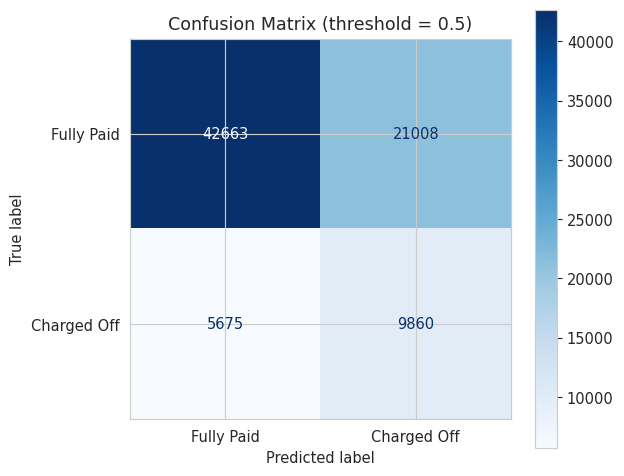

In [29]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=["Fully Paid","Charged Off"]).plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()


**Reading the confusion matrix:** At the default 0.5 threshold, the model correctly identifies **~64% of actual defaulters** (recall for Charged Off) but at the cost of a lot of false alarms -- only **~32% of everyone it flags as "will default" actually does** (precision for Charged Off). This is the direct result of using `class_weight='balanced'`, which deliberately trades precision for recall on the minority class -- the tradeoff we dig into below (Section 11.4).

### 11.2 ROC AUC Curve

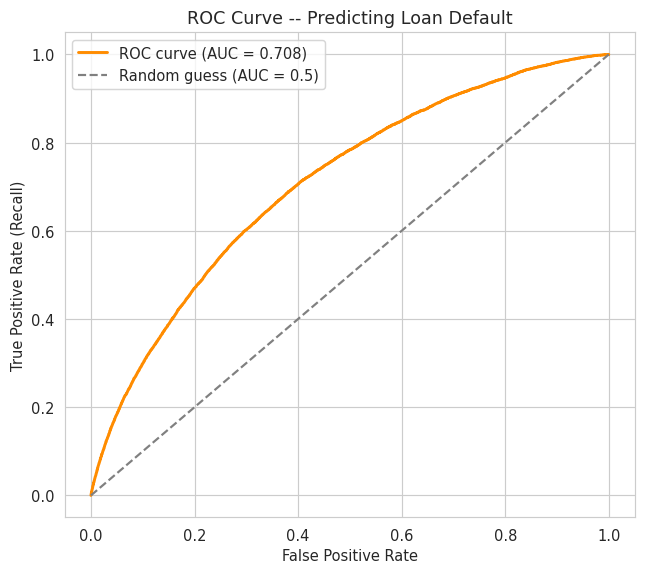

In [30]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve -- Predicting Loan Default")
plt.legend()
plt.show()


**Comment:** The model achieves an **ROC AUC of about 0.71** -- meaningfully better than random guessing (0.5), showing the model has real, if moderate, ability to rank riskier applicants above safer ones across all thresholds. This is a realistic result for a model built only on the applicant's *stated financial profile* (no external credit bureau score is included in this dataset) -- it captures a genuine signal without being a "solved" problem, which is expected for consumer credit risk.

### 11.3 Precision-Recall Curve

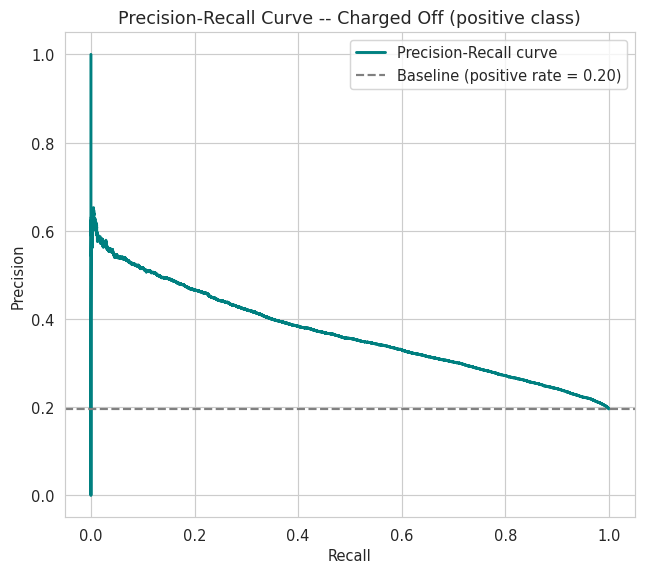

In [31]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
baseline = y_test.mean()

plt.figure(figsize=(7,6))
plt.plot(recalls, precisions, color="teal", lw=2, label="Precision-Recall curve")
plt.axhline(baseline, color="gray", linestyle="--", label=f"Baseline (positive rate = {baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve -- Charged Off (positive class)")
plt.legend()
plt.show()


**Comment:** The Precision-Recall curve shows the fundamental tradeoff clearly: pushing recall higher (catching more real defaulters) steadily costs precision (more good applicants get wrongly flagged). Because "Charged Off" is the minority class (~20% baseline), even a genuinely useful model's precision curve sits well below 1.0 across most of the recall range -- this is normal for imbalanced classification, not a sign the model is broken.

### 11.4 Precision-Recall Tradeoff -- the Core Business Question

We now directly answer the two tradeoff questions posed by LoanTap, using the threshold
(cutoff on predicted probability) as the lever.

In [32]:
thresh_grid = np.arange(0.1, 0.95, 0.05)
rows = []
for t in thresh_grid:
    pred_t = (y_proba >= t).astype(int)
    prec = precision_score(y_test, pred_t, zero_division=0)
    rec = recall_score(y_test, pred_t, zero_division=0)
    f1 = f1_score(y_test, pred_t, zero_division=0)
    rows.append([t, prec, rec, f1])

thresh_df = pd.DataFrame(rows, columns=["threshold","precision","recall","f1"])
print(thresh_df.round(3))


    threshold  precision  recall     f1
0        0.10      0.196   1.000  0.328
1        0.15      0.198   0.998  0.331
2        0.20      0.205   0.990  0.340
3        0.25      0.216   0.970  0.354
4        0.30      0.230   0.931  0.369
5        0.35      0.248   0.879  0.387
6        0.40      0.268   0.809  0.403
7        0.45      0.293   0.729  0.418
8        0.50      0.319   0.635  0.425
9        0.55      0.347   0.534  0.421
10       0.60      0.375   0.431  0.401
11       0.65      0.406   0.335  0.367
12       0.70      0.442   0.252  0.321
13       0.75      0.480   0.172  0.253
14       0.80      0.515   0.097  0.163
15       0.85      0.554   0.039  0.072
16       0.90      0.636   0.006  0.011


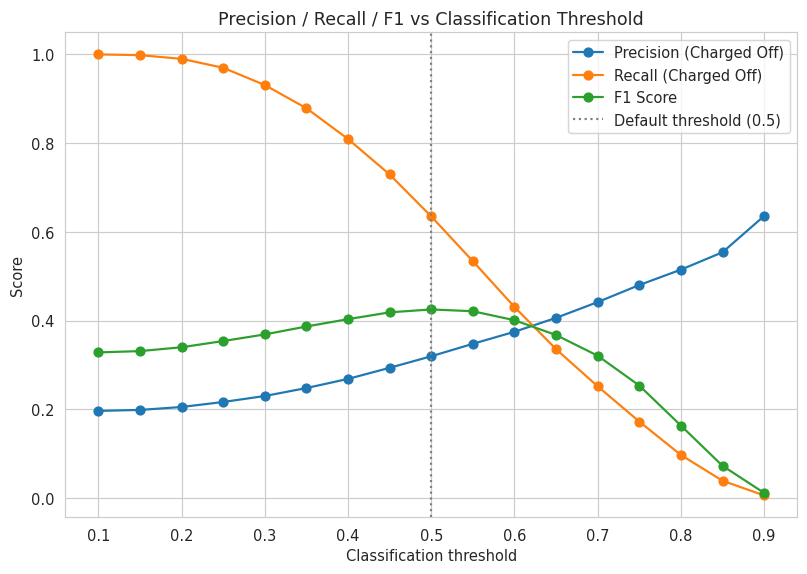

In [33]:
plt.figure(figsize=(9,6))
plt.plot(thresh_df["threshold"], thresh_df["precision"], marker="o", label="Precision (Charged Off)")
plt.plot(thresh_df["threshold"], thresh_df["recall"], marker="o", label="Recall (Charged Off)")
plt.plot(thresh_df["threshold"], thresh_df["f1"], marker="o", label="F1 Score")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Classification Threshold")
plt.legend()
plt.show()


**Q: How can we make sure our model detects real defaulters with fewer false positives (so we don't lose good business)?**
Raising the classification threshold (e.g., from 0.5 to ~0.6-0.7) makes the model more conservative about labeling someone "high risk" -- it only flags the applicants it's most confident about, which **raises precision** (fewer false positives, i.e., fewer good applicants wrongly rejected) but **lowers recall** (some real defaulters slip through undetected). This is the right move when LoanTap wants to **protect growth and approval volume**, accepting a bit more default risk in exchange for financing more good customers.

**Q: Since NPAs are a real problem, we should play safe and not disburse to risky applicants -- how?**
Lowering the classification threshold (e.g., from 0.5 to ~0.3-0.4) makes the model flag more applicants as "risky," which **raises recall** (catches more real defaulters before they're funded) at the cost of **lower precision** (more good applicants incorrectly rejected too). This is the right move when **capital protection / minimizing NPAs is the priority**, even if it means turning away some creditworthy applicants.

**There is no threshold that maximizes both simultaneously** -- this is the fundamental precision-recall tradeoff, and the correct choice depends on which mistake costs LoanTap more (see Section 12, Q6-Q7).

## 12. Questionnaire Answers

**Q1. What percentage of customers have fully paid their loan amount?**
**80.39%** of the 396,030 applicants in this dataset fully paid their loan (318,357 out of 396,030); the remaining 19.61% charged off.

**Q2. Comment on the correlation between Loan Amount and Installment.**
`loan_amnt` and `installment` are **very strongly, positively correlated (r ≈ 0.95)** — expected, since the monthly installment is mathematically derived from the loan amount (along with interest rate and term). This near-perfect correlation is exactly what triggered its removal via the VIF check in Section 9.

**Q3. The majority of people have home ownership as _______.**
**MORTGAGE** (50.1% of all applicants), followed by RENT (40.3%) and OWN (9.5%).

**Q4. People with grade 'A' are more likely to fully pay their loan. (T/F)**
**True.** Grade-A borrowers fully pay 93.7% of the time, versus 80.4% overall and as low as 52.2% for grade-G — confirmed both by the crosstab in Section 4 and by `grade_num` being one of the strongest, most significant risk-raising coefficients in the model (Section 10.2).

**Q5. Name the top 2 most common job titles.**
**Teacher** (4,389 applicants) and **Manager** (4,250 applicants) are the two most frequently listed job titles.

**Q6. Thinking from a bank's perspective, which metric should our primary focus be on?**
**Recall** (for the "Charged Off" / default class). A missed defaulter (false negative) costs LoanTap the **entire outstanding principal** -- a direct capital loss and the exact NPA problem the business is trying to avoid. A wrongly-rejected good applicant (false positive, the cost of prioritizing recall) only costs LoanTap the **potential interest income** it would have earned -- a smaller, opportunity-cost-only loss. Since the downside of a false negative is structurally larger than the downside of a false positive in lending, **Recall should be the primary metric**, while precision is monitored as a guardrail (see Q7) rather than the main optimization target. (ROC AUC remains useful as an overall, threshold-independent ranking-quality metric, and F1 balances both — but neither directly reflects this asymmetric business cost.)

**Q7. How does the gap between precision and recall affect the bank?**
A **large precision-recall gap** means the model behaves very differently depending on which error type it's minimizing. If the bank pushes recall very high (to protect against NPAs), precision drops sharply -- e.g., at threshold 0.30 recall is 93.1% but precision is only 23.0%, meaning roughly 3 out of 4 applicants flagged "high risk" would have actually paid in full. Rejecting all of them protects capital but **turns away a large amount of genuinely good, profitable business** -- a real growth/revenue cost, not just a statistical footnote. Conversely, pushing precision high (to approve more business) lets many real defaulters through. **The size of the gap is a direct measure of how much one goal must be sacrificed for the other**, and LoanTap needs to pick an operating threshold deliberately (see Section 11.4) rather than defaulting to 0.5 without discussion.

**Q8. Which features heavily affected the outcome?**
Ranked by statistical significance and coefficient size (Section 10.2), the strongest **risk-raising** features are: `grade_num` (LoanTap's own risk grade), `dti` (debt-to-income ratio), `purpose_small_business`, `term_num` (60-month term), `open_acc`, `revol_util`, and income-verification status. The strongest **risk-lowering** features are `annual_inc` (higher income), `pub_rec_bankruptcies_flag` (interestingly negative once other factors are controlled for -- likely reflecting that post-bankruptcy borrowers who still qualify have already been pre-screened), and joint-application status. **`installment` and `int_rate` were removed for multicollinearity** but their information is still captured indirectly through `grade_num` and `installment`'s VIF-surviving relationship with loan size.

**Q9. Will the results be affected by geographical location? (Yes/No)**
**No.** Every one-hot `state_grp_*` coefficient in the final model is small in magnitude (all |coef| < 0.06, versus 0.45+ for `grade_num`/`dti`) **and none are statistically significant at α = 0.05** (Section 10.2). Applicant-level financial and credit attributes (grade, DTI, income, credit history) drive the outcome far more than which state the applicant lives in -- geography is not a meaningful predictor of default risk in this data.


## 13. Actionable Insights & Recommendations

### Model Summary
- Final Logistic Regression (class-weighted, VIF-cleaned, 49 features): **ROC AUC ≈ 0.71**, and at the default 0.5 threshold, **63.5% recall / 31.9% precision** on the "Charged Off" class.
- Performance is **good-but-moderate**, appropriate for a model built purely from the applicant's self-reported financial/credit profile (no external bureau score) -- it adds real, usable signal to underwriting without being a fully "solved" risk model.

### Recommendations for LoanTap

1. **Adopt a deliberately-chosen threshold, not the 0.5 default.** Given lending's asymmetric costs (a missed defaulter costs the full principal; a wrongly-rejected good applicant only costs potential interest), we recommend operating **below 0.5 (e.g., ~0.30-0.35)** to prioritize recall and catch more real defaulters -- accepting the tradeoff of rejecting more borderline-good applicants. The exact cutoff should be tuned against LoanTap's actual cost-per-NPA vs. profit-per-loan economics.
2. **Use `grade`, `dti`, loan `purpose`, `term`, and `annual_inc` as the primary underwriting levers** -- these are the strongest, most significant, most stable predictors. Small-business-purpose loans and 60-month terms in particular warrant extra scrutiny or risk-based pricing.
3. **Introduce tiered terms based on predicted risk**, rather than a single accept/reject cutoff: e.g., approve low-predicted-risk applicants at standard rates, offer higher-risk-but-still-approved applicants a **shorter term (36 months) and/or a lower loan cap** to reduce exposure, instead of an outright rejection -- this preserves some business from the "gray zone" applicants while still managing risk.
4. **Don't build state/geography into underwriting rules** -- Q9's finding (no significant state effect) means LoanTap should avoid geographic pricing or eligibility differences; they wouldn't be justified by this data and could raise fair-lending concerns.
5. **Enrich the model with external data for a meaningful accuracy jump**: a real credit bureau score (e.g., FICO-equivalent for the applicant's market), employment-verification data, or bank-transaction/cash-flow data would likely lift ROC AUC well above the current ~0.71 -- self-reported financial fields alone have a ceiling.
6. **Re-validate the model periodically** (e.g., quarterly) as LoanTap's applicant mix and macroeconomic conditions shift -- a model trained on one period's data can drift; monitor recall/precision on fresh cohorts and retrain when performance degrades.
7. **Present the threshold tradeoff explicitly to business stakeholders** (Section 11.4's chart) whenever the cutoff is revisited -- this turns a purely technical decision into an informed business choice about risk appetite vs. growth.
